# Análises

In [ ]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

ALGOS = ["DT", "RF", "SVM", "NB", "KNN"]
K = len(ALGOS)          # numero de algoritmos

plt.rcParams["figure.dpi"] = 110

SIX_APPROACHES = ["AR", "MR", "Vitórias significativas",
                   "Abordagem 1 (regressor sobre P)",
                   "Abordagem 2 (regressor sobre R)",
                   "HARRIS (lambda=0.5)"]

# Rótulos curtos usados nas tabelas e figuras.
APPROACH_LABELS = {
    "Abordagem 1 (regressor sobre P)": "Abordagem 1",
    "Abordagem 2 (regressor sobre R)": "Abordagem 2",
}
SIX_LABELS = [APPROACH_LABELS.get(a, a) for a in SIX_APPROACHES]

lodo_path = os.path.join(RESULTS_DIR, "lodo_results_30.csv")
assert os.path.exists(lodo_path), (
    "Rode antes o notebook 02_leave_one_out.ipynb para gerar "
    "results/lodo_results_30.csv."
)
lodo_df = pd.read_csv(lodo_path)
print(f"lodo_df carregado de '{lodo_path}': {lodo_df.shape[0]} linhas x "
      f"{lodo_df.shape[1]} colunas "
      f"({lodo_df['approach'].nunique()} configurações x "
      f"{lodo_df['dataset'].nunique()} datasets)")

lodo_df carregado de 'd:\Projetos\DisciplinaMtL\results\lodo_results_30.csv': 300 linhas x 9 colunas (10 configurações x 30 datasets)


### 3.1 Correlação de Spearman

In [ ]:
six_df = lodo_df[lodo_df["approach"].isin(SIX_APPROACHES)].copy()
six_df["approach"] = six_df["approach"].replace(APPROACH_LABELS)

spearman_summary = (
    six_df.groupby("approach")["spearman"]
    .agg(["mean", "std"])
    .reindex(SIX_LABELS)
    .rename(columns={"mean": "spearman_médio", "std": "desvio_padrão_spearman"}) #média sobre as 30 rodadas
)
spearman_summary

,spearman_médio,desvio_padrão_spearman
approach,,
AR,0.581011,0.315662
MR,0.649268,0.315354
Vitórias significativas,0.634365,0.312421
Abordagem 1,0.644365,0.304957
Abordagem 2,0.593845,0.379005
HARRIS (lambda=0.5),0.250129,0.446804


### Curva de perda por número de testes

AUC (perda média, menor é melhor):


,AUC_médio,desvio_padrão_auc
approach,,
AR,0.006534,0.008259
MR,0.003851,0.006219
Vitórias significativas,0.003851,0.006219
Abordagem 1,0.003862,0.006217
Abordagem 2,0.004564,0.006626
HARRIS (lambda=0.5),0.014394,0.019775


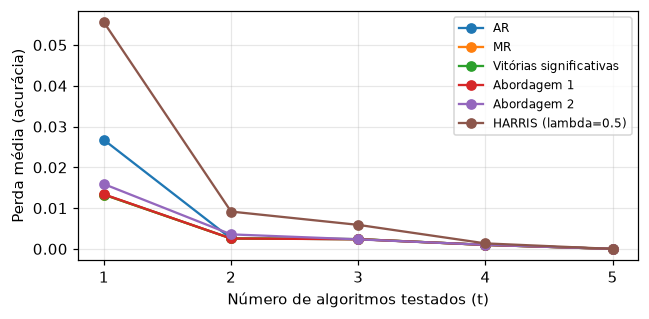

In [79]:
loss_cols = [f"loss_t{t+1}" for t in range(K)]

auc_summary = (
    six_df.groupby("approach")["auc_loss"]
    .agg(["mean", "std"])
    .reindex(SIX_LABELS)
    .rename(columns={"mean": "AUC_médio", "std": "desvio_padrão_auc"})
)
print("AUC (perda média, menor é melhor):")
display(auc_summary)

mean_curves = (
    six_df.groupby("approach")[loss_cols].mean().reindex(SIX_LABELS)
)

fig, ax = plt.subplots(figsize=(6, 3))
for approach in SIX_LABELS:
    ax.plot(range(1, K + 1), mean_curves.loc[approach].values,
            marker="o", label=approach)
ax.set_xlabel("Número de algoritmos testados (t)")
ax.set_ylabel("Perda média (acurácia)")
# ax.set_title("Curva de perda média por número de testes (LODO, 30 datasets)")
ax.set_xticks(range(1, K + 1))
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "curva_perda_media.png"))
plt.show()

### Efeito de $\lambda$ no HARRIS

,spearman_médio,AUC_médio
lambda,,
0.00,0.266976,0.013330
0.25,0.204306,0.014967
0.50,0.250129,0.014394
0.75,0.196622,0.017421
1.00,0.141319,0.018700


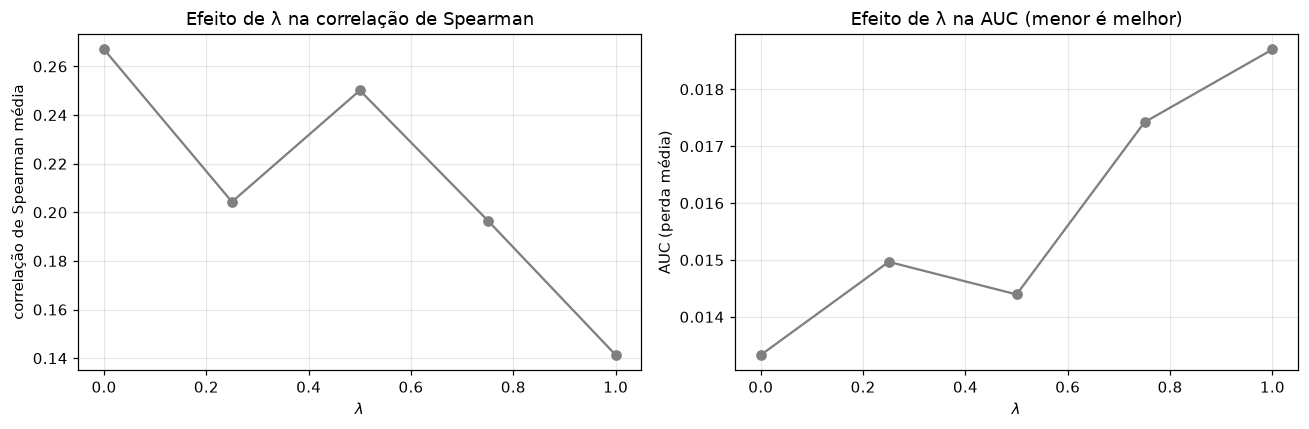

In [81]:

harris_df = lodo_df[lodo_df["approach"].str.startswith("HARRIS")].copy()
harris_df["lambda"] = harris_df["approach"].str.extract(r"lambda=([\d.]+)").astype(float)

harris_summary = (
    harris_df.groupby("lambda")[["spearman", "auc_loss"]]
    .mean()
    .rename(columns={"spearman": "spearman_médio", "auc_loss": "AUC_médio"})
)
display(harris_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(harris_summary.index, harris_summary["spearman_médio"], marker="o", color="gray")
axes[0].set_xlabel(r"$\lambda$")
axes[0].set_ylabel("correlação de Spearman média")
axes[0].set_title("Efeito de λ na correlação de Spearman")
axes[0].grid(alpha=0.3)

axes[1].plot(harris_summary.index, harris_summary["AUC_médio"], marker="o", color="gray")
axes[1].set_xlabel(r"$\lambda$")
axes[1].set_ylabel("AUC (perda média)")
axes[1].set_title("Efeito de λ na AUC (menor é melhor)")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "efeito_lambda_harris.png"))
plt.show()


### Testes estatísticos (Friedman + Nemenyi)

=== Diagrama de diferença crítica — correlação de Spearman (maior é melhor) ===
Friedman: estatística=37.180, p-valor=5.512e-07


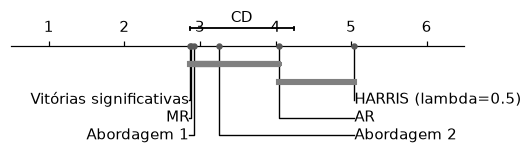

CD (Nemenyi, alpha=0.05) = 1.377

=== Diagrama de diferença crítica — AUC da curva de perda (menor é melhor) ===
Friedman: estatística=22.460, p-valor=0.000428


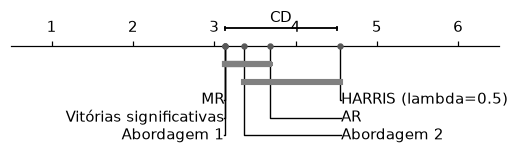

CD (Nemenyi, alpha=0.05) = 1.377


In [ ]:
import numpy as np
from scipy.stats import studentized_range


def plot_critical_difference(df_wide, higher_is_better, title, filename, alpha=0.05):
    stat, p_friedman = friedmanchisquare(*[df_wide[c] for c in df_wide.columns])
    print(f"Friedman: estatística={stat:.3f}, p-valor={p_friedman:.4g}")

    ascending = not higher_is_better  # rank 1 = melhor
    avg_ranks = df_wide.rank(axis=1, ascending=ascending).mean()

    sig_matrix = sp.posthoc_nemenyi_friedman(df_wide.values)
    sig_matrix.columns = df_wide.columns
    sig_matrix.index = df_wide.columns

    n_datasets, k = df_wide.shape
    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    cd = q_alpha * np.sqrt(k * (k + 1) / (6 * n_datasets))

    fig, ax = plt.subplots(figsize=(5, 1.5))
    sp.critical_difference_diagram(
        avg_ranks, sig_matrix, ax=ax,
        label_fmt_left="{label}", label_fmt_right="{label}",
        elbow_props={"color": "black", "linewidth": 0.9},
        crossbar_props={"color": "gray", "linewidth": 4.0},
        marker_props={"color": "0.35", "s": 10},
    )

    x0, y0, tick = avg_ranks.min(), 1.0, 0.08
    ax.plot([x0, x0 + cd], [y0, y0], color="black", linewidth=1.2)
    ax.plot([x0, x0], [y0 - tick, y0 + tick], color="black", linewidth=1.2)
    ax.plot([x0 + cd, x0 + cd], [y0 - tick, y0 + tick], color="black", linewidth=1.2)
    ax.text(x0 + cd / 2, y0 + 0.15, "CD", ha="center", va="bottom")

    ax.set_xlim(0.5, k + 0.5)
    ax.set_xticks(range(1, k + 1))
    # ax.set_title(title)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, filename))
    plt.show()
    print(f"CD (Nemenyi, alpha={alpha:g}) = {cd:.3f}")
    return p_friedman, avg_ranks


spearman_wide = six_df.pivot(index="dataset", columns="approach", values="spearman")[SIX_LABELS]
auc_wide = six_df.pivot(index="dataset", columns="approach", values="auc_loss")[SIX_LABELS]

print("=== Diagrama de diferença crítica — correlação de Spearman (maior é melhor) ===")
p_friedman_spearman, ranks_spearman = plot_critical_difference(
    spearman_wide, higher_is_better=True,
    title="Diferença crítica — correlação de Spearman (LODO)",
    filename="cd_diagram_spearman.png")

print("\n=== Diagrama de diferença crítica — AUC da curva de perda (menor é melhor) ===")
p_friedman_auc, ranks_auc = plot_critical_difference(
    auc_wide, higher_is_better=False,
    title="Diferença crítica — AUC da curva de perda (LODO)",
    filename="cd_diagram_auc.png")

### Overview das seis abordagens


In [78]:

summary = spearman_summary.join(auc_summary)
summary["rank_médio_spearman"] = ranks_spearman.reindex(summary.index)
summary["rank_médio_auc"] = ranks_auc.reindex(summary.index)
summary = summary.sort_values("spearman_médio", ascending=False)
summary


,spearman_médio,desvio_padrão_spearman,AUC_médio,desvio_padrão_auc,rank_médio_spearman,rank_médio_auc
approach,,,,,,
MR,0.649268,0.315354,0.003851,0.006219,2.883333,3.133333
Abordagem 1,0.644365,0.304957,0.003862,0.006217,2.916667,3.133333
Vitórias significativas,0.634365,0.312421,0.003851,0.006219,2.866667,3.133333
Abordagem 2,0.593845,0.379005,0.004564,0.006626,3.250000,3.366667
AR,0.581011,0.315662,0.006534,0.008259,4.050000,3.683333
HARRIS (lambda=0.5),0.250129,0.446804,0.014394,0.019775,5.033333,4.550000
